# Take-Home Assessment 5: Creative Component

An important consideration when making any kind of visualization is ensuring that our visualizations are accessible to all users, including those with visual impairments or color vision deficiencies.

**Task:** Choose 2 plots from your Technical Component implementations and conduct an accessibility audit on each. After identifying accessibility issues, modify your code to improve the accessibility of these visualizations.

For these tasks, you may copy over any code that you wrote as part of your initial solution to `hw5.py` for loading/joining data, or for creating the plots. Your plotting code is expected to have some modifications to address the accessibility issue(s) you may have found during your audit.

### Requirements

For each of your 2 chosen plots:

1. **Audit:** Use the provided accessibility tools to evaluate your plot for common accessibility issues, such as:
    * Color contrast and distinguishability
    * Colorblind-friendly palettes
    * Font size and readability
    * Alternative text descriptions

2. **Modify:** Update your code to address the accessibility issues you identified. Your modifications might include:

    * Adjusting color schemes to improve contrast or accommodate color vision deficiencies
    * Increasing font sizes for better readability
    * Adding or improving alt text descriptions that convey the key insights of the visualization (note: `matplotlib` does not currently support adding alt text directly to a plot, but you can add alt text to images in Markdown!)
    * Modifying plotting elements (borders, patterns, labels) to improve visual clarity

3. **Explain:** In the provided markdown cells in `hw5_creative.ipynb`, for each plot, write 3-5 sentences explaining:

    * What accessibility issues you identified
    * What specific changes you made to your code
    * How these changes improve accessibility for users with different needs

You do not need to save your plots to new files, but they should be visible in the output of your code!

## Accessibility Audit Resources

* [WebAIM's Contrast Checker](https://webaim.org/resources/contrastchecker/): To use this tool, click on the "color picker" on either the Foreground or Background. Select the colors you want to check the contrast of, using the eyedropper tool. The site will provide a contrast ratio, as well as whether these colors would pass WCAG guidelines if they are used as text.
* [AccessibleWeb's Color Contrast Checker](https://accessibleweb.com/color-contrast-checker/): Works pretty much the same way as the above, but with an alternate interface.
* [Coblis Color Blindness Simulator](https://www.color-blindness.com/coblis-color-blindness-simulator/): Upload an image in the provided file upload area, then select one of the options from "Anomalous Trichromacy", "Diochromatic view", or "Monochromatic view" to see what it would look like with other types of color blindness.
* [Harvard University's Digital Accessibility Services Guidelines for Alt Text](https://accessibility.huit.harvard.edu/describe-content-images): An article explaining alt text, with examples for adding alt text to different kinds of visualizations.
* [Codecademy's guide to adding images in Markdown](https://www.codecademy.com/resources/docs/markdown/images): An article explaining how to add images to Markdown, including adding alt text.

In [2]:
import geopandas as gpd
import matplotlib.pyplot as plt

%matplotlib.inline

UsageError: Line magic function `%matplotlib.inline` not found.


## Your first plot!

1. What tool(s) did you use for your accessibility audit? What were the initial results?

I chose plot_food_access_by_county because it uses multiple choropleth maps and it is easy for accessibility issues to show up there.

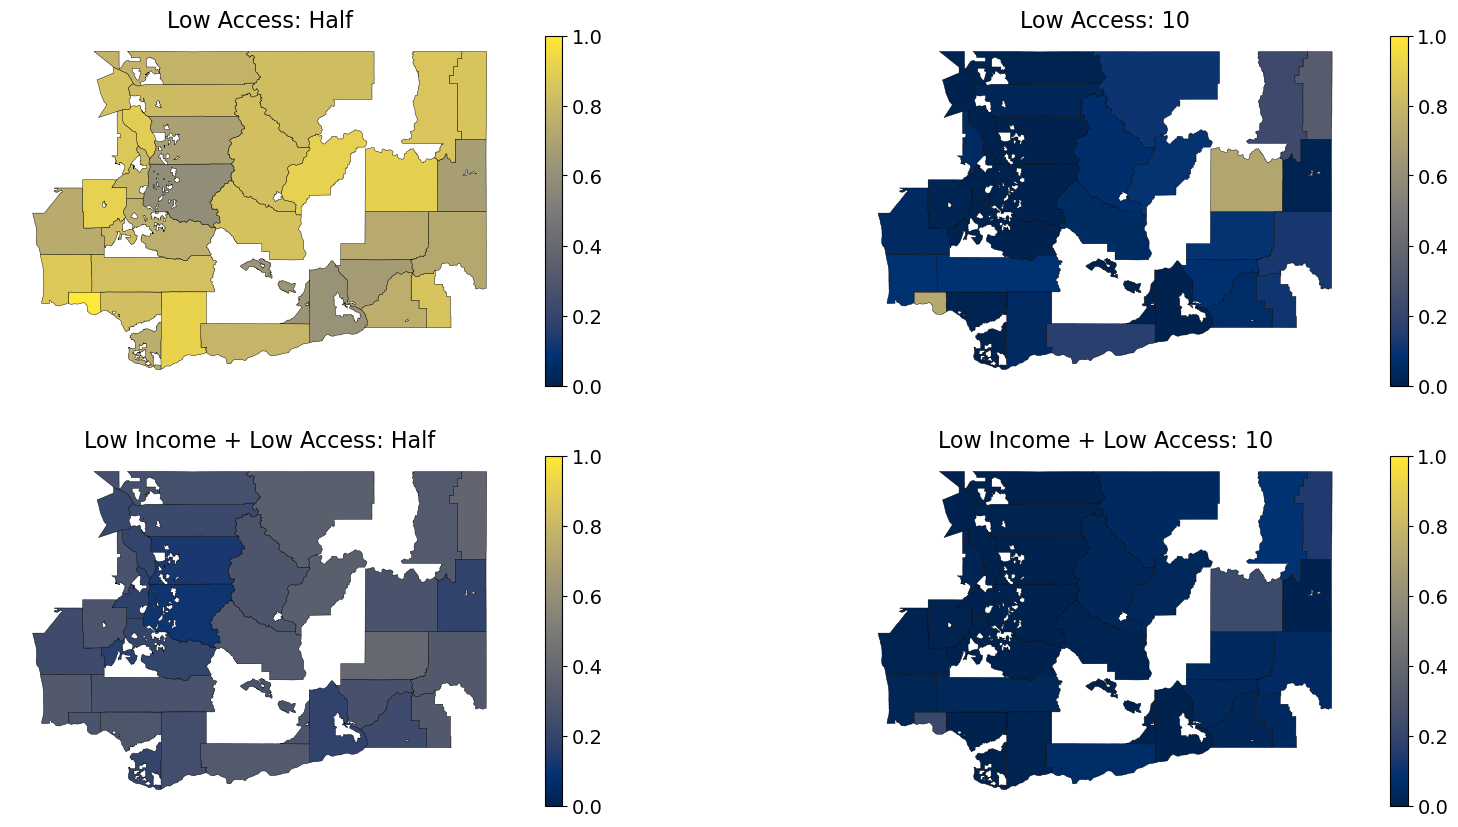

In [3]:
def _no_array_interface(self):
    raise AttributeError


try:
    from shapely.geometry.base import BaseGeometry
    from shapely.geometry import (
        Point, MultiPoint, LineString, MultiLineString,
        Polygon, MultiPolygon, GeometryCollection
    )

    for _cls in [
        BaseGeometry, Point, MultiPoint, LineString, MultiLineString,
        Polygon, MultiPolygon, GeometryCollection
    ]:
        try:
            _cls.__array_interface__ = property(_no_array_interface)
        except Exception:
            pass
except Exception:
    pass


census_file = "food_access/tl_2010_53_tract00/tl_2010_53_tract00.shp"
food_file = "food_access/food_access.csv"

census = gpd.read_file(census_file)
food = pd.read_csv(food_file)
data = census.merge(food, left_on="CTIDFP00", right_on="CensusTract", how="left")

cols = ["County", "geometry", "POP2010", "lapophalf", "lapop10", "lalowihalf", "lalowi10"]
county = data[cols].copy()
county = county[county["County"].notna()].copy()

numeric_cols = ["POP2010", "lapophalf", "lapop10", "lalowihalf", "lalowi10"]
county[numeric_cols] = county[numeric_cols].fillna(0)

county = county.dissolve(by="County", aggfunc="sum")

pop = county["POP2010"].replace(0, pd.NA)
county["lapophalf_ratio"] = (county["lapophalf"] / pop).fillna(0)
county["lapop10_ratio"] = (county["lapop10"] / pop).fillna(0)
county["lalowihalf_ratio"] = (county["lalowihalf"] / pop).fillna(0)
county["lalowi10_ratio"] = (county["lalowi10"] / pop).fillna(0)

plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 16,
})

fig, [[ax1, ax2], [ax3, ax4]] = plt.subplots(2, 2, figsize=(20, 10))

def draw(ax, column, title):
    county.plot(color="#EEEEEE", ax=ax)
    county.plot(
        column=column,
        ax=ax,
        vmin=0,
        vmax=1,
        legend=True,
        cmap="cividis",
        edgecolor="black",
        linewidth=0.3
    )
    ax.set_title(title)
    ax.set_axis_off()

draw(ax1, "lapophalf_ratio", "Low Access: Half")
draw(ax2, "lapop10_ratio", "Low Access: 10")
draw(ax3, "lalowihalf_ratio", "Low Income + Low Access: Half")
draw(ax4, "lalowi10_ratio", "Low Income + Low Access: 10")

plt.show()

2. What did you change from your original solution, and why? How is your plot more accessible now?


The original version relies on subtle color differences, and that can be rough for color vision deficiency or even just low contrast screens. The legends are also small by default, so it is harder to read quickly. I switched to a colorblind friendly colormap (cividis), increased the font sizes, and added thin black borders so county shapes separate clearly even if the colors look similar. This makes the plot easier to read without changing the underlying data or story.

## Your second plot!

1. What tool(s) did you use for your accessibility audit? What were the initial results?

I chose plot_low_access_tracts because it is layered and the visibility of each layer matters a lot.

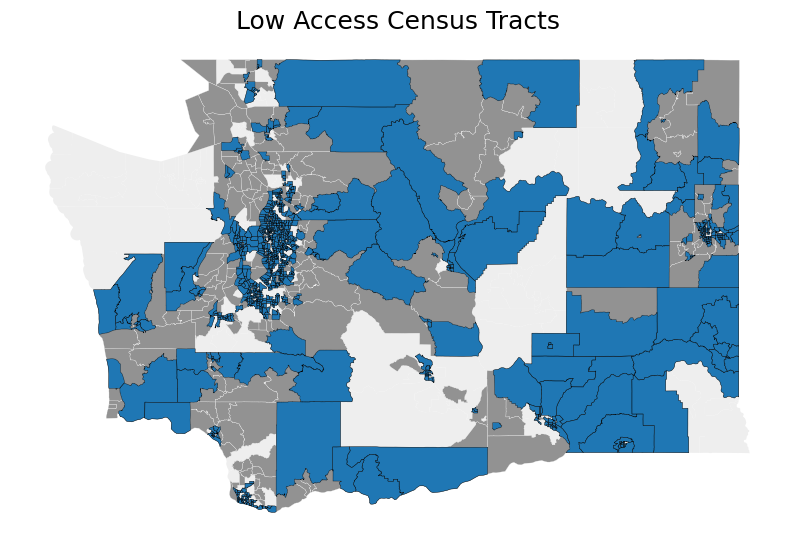

In [4]:
def _no_array_interface(self):
    raise AttributeError


try:
    from shapely.geometry.base import BaseGeometry
    from shapely.geometry import (
        Point, MultiPoint, LineString, MultiLineString,
        Polygon, MultiPolygon, GeometryCollection
    )

    for _cls in [
        BaseGeometry, Point, MultiPoint, LineString, MultiLineString,
        Polygon, MultiPolygon, GeometryCollection
    ]:
        try:
            _cls.__array_interface__ = property(_no_array_interface)
        except Exception:
            pass
except Exception:
    pass


census_file = "food_access/tl_2010_53_tract00/tl_2010_53_tract00.shp"
food_file = "food_access/food_access.csv"

census = gpd.read_file(census_file)
food = pd.read_csv(food_file)
data = census.merge(food, left_on="CTIDFP00", right_on="CensusTract", how="left")

data[["POP2010", "lapophalf", "lapop10"]] = data[["POP2010", "lapophalf", "lapop10"]].fillna(0)
pop = data["POP2010"].replace(0, pd.NA)

urban_mask = data["Urban"] == 1
rural_mask = data["Urban"] == 0

urban_low = (data["lapophalf"] >= 500) | ((data["lapophalf"] / pop) >= 0.33)
rural_low = (data["lapop10"] >= 500) | ((data["lapop10"] / pop) >= 0.33)

low_access = ((urban_mask & urban_low) | (rural_mask & rural_low)).fillna(False)
has_food = data["County"].notna()

plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 18,
})

fig, ax = plt.subplots(figsize=(10, 10))

data.plot(color="#EEEEEE", ax=ax)

data.loc[has_food].plot(
    color="#888888",
    edgecolor="white",
    linewidth=0.2,
    alpha=0.9,
    ax=ax
)

data.loc[low_access].plot(
    color="#1f77b4",
    edgecolor="black",
    linewidth=0.3,
    alpha=1.0,
    ax=ax
)

ax.set_title("Low Access Census Tracts")
ax.set_axis_off()
plt.show()

2. What did you change from your original solution, and why? How is your plot more accessible now?

The main problem here is that if the gray layer and the blue layer blend, it becomes hard to tell what is actually low access, especially for people with low vision or on low quality displays. I used a darker gray for the background tracts that still keeps the blue highlight visible, added borders to separate shapes, and removed axis clutter so the map is the focus. The end result is that the low access regions stand out more clearly while the context layer stays readable.

## Submitting your work

Make sure to refer to the Take-Home Assessment 5 Guidelines for submission details. When you are submitting your notebook, make sure that the output for all cells is visible. You can do this by **running all cells** before turning in your notebook!